### El Perceptron NAND

In [22]:
# Importacion
import sys, os
sys.path.append(os.path.abspath('..'))
from michigrad.engine import Value
from michigrad.visualize import show_graph
import matplotlib.pyplot as plt
import numpy as np

In [23]:
# Definimos las variables de entrada y las salidas deseadas

x00 = Value(0., name='x0=0')
x01 = Value(1., name='x0=1')
x10 = Value(0., name='x1=0')
x11 = Value(1., name='x1=1')

y0 =  Value(1., name='y0=0')
y1 =  Value(0., name='y1=0')


In [24]:
# Definimos la funcion de activacion, este caso vamos usan la funcion tangente hiperbolica
def tanh(x: Value):
    return (x.exp() - (-x).exp()) / (x.exp() + (-x).exp())

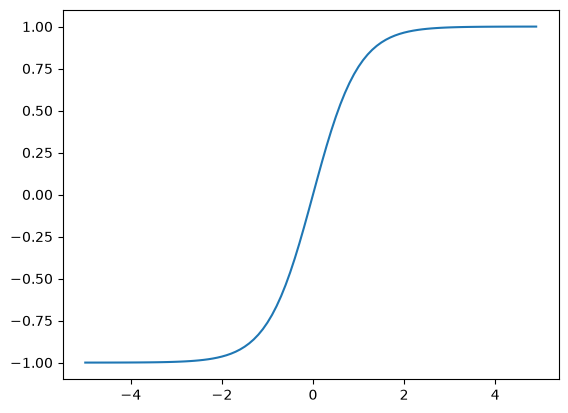

In [25]:
# Mostramos el grafico de la funcion de activacion
x = np.arange(-5, 5, 0.1)
s = []
for i in x:
    s.append(tanh(Value(i)).data) 
    
plt.plot(x, s)

In [26]:
# Definimos los pesos y bias de la red neuronal
w0 = Value(np.random.random(), name='w0')
w1 = Value(np.random.random(), name='w1')
b = Value(np.random.random(), name='bias')

### Forward Pass

In [27]:
tanh(x00*w0 + x11*w1 + b)

Value(data=0.6482435596875862, grad=0, name=)

In [28]:
yhat00 = tanh(x00*w0 + x10*w1 + b)
yhat01 = tanh(x00*w0 + x11*w1 + b)
yhat10 = tanh(x01*w0 + x10*w1 + b)
yhat11 = tanh(x01*w0 + x11*w1 + b)

print(yhat00, yhat01, yhat10, yhat11)

Value(data=0.09462222037586288, grad=0, name=) Value(data=0.6482435596875862, grad=0, name=) Value(data=0.16492425918304318, grad=0, name=) Value(data=0.6878173738331999, grad=0, name=)


### Lost Function

In [29]:
# Calculo de la funcion de perdida
L = ((y0-yhat00)**2 + (y0-yhat01)**2 + (y0-yhat10)**2 + (y1 - yhat11)**2)/4
L.name = 'L'
L

Value(data=0.5284714374465456, grad=0, name=L)

### Grafo de operaciones

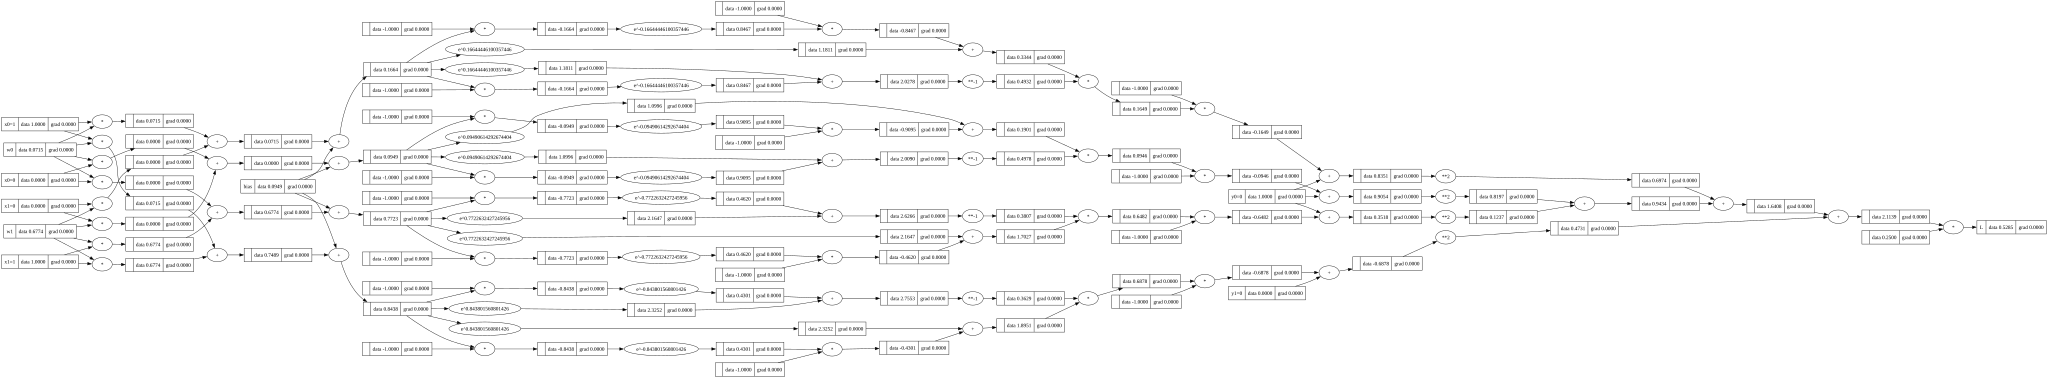

In [30]:
show_graph(L)

### Backpropagation

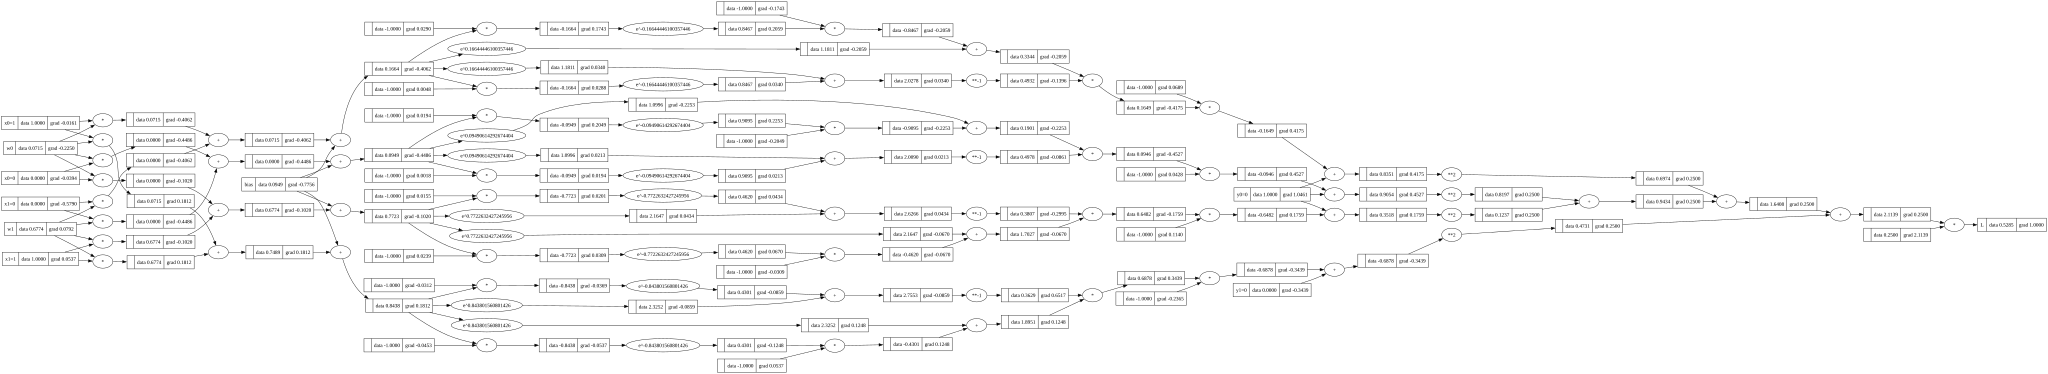

In [31]:
L.backward()
show_graph(L)

### Training Loop

In [32]:
# Ahora aplicamos el training loop para que el modelo sepa resolver
for i in range(10000):
    # Forward pass
    yhat00 = tanh(x00*w0 + x10*w1 + b)
    yhat00.name = 'y00'
    yhat01 = tanh(x00*w0 + x11*w1 + b)
    yhat01.name = 'y01'
    yhat10 = tanh(x01*w0 + x10*w1 + b)
    yhat10.name = 'y10'
    yhat11 = tanh(x01*w0 + x11*w1 + b) # Forward pass -> Ejecutar el modelo
    yhat11.name = 'y11'
    # Lost Function
    L = ((y0-yhat00)**2 + (y0-yhat01)**2 + (y0-yhat10)**2 + (y1 - yhat11)**2)/4 # Calcular la funcion de perdida
    L.name = 'L'
    # Zero Grad
    w0.grad = 0 # Poner todos los gradiente de la corrida en 0
    w1.grad = 0
    b.grad = 0
    # Backpropagation
    L.backward() # Aplicar el algoritmo de backpropagation en el grafo de operaciones
    # Realizar el update. Es decir, movernos en la direccion contraria al gradiente
    # el cual se suele multiplicar por un valor muy chiquito. Esto ultimo se llama learning rate que seria que tan brusco es el cambio de W
    w0.data -= w0.grad * 0.1
    w1.data -= w1.grad * 0.1
    b.data -= b.grad * 0.1
    print(L.data)

0.5284714374465456
0.46764031283740487
0.4236316782311635
0.39118165919458103
0.3667036515965798
0.3478098864557221
0.3329080372712422
0.3209214517557635
0.3111082174448661
0.3029464990461536
0.2960617329751881
0.2901798317342874
0.2850965987263302
0.2806573671689866
0.2767431911336767
0.27326130968212164
0.2701384477812457
0.2673160334936498
0.26474673137004223
0.2623918942472155
0.2602196654550421
0.25820354808379486
0.2563213140352063
0.25455416328395625
0.2528860694917817
0.2513032658939117
0.2497938378252228
0.2483473970750173
0.2469548195826971
0.245608032568433
0.2442998405470376
0.2430237821526762
0.24177401155209965
0.2405451996170667
0.23933245108477152
0.23813123474601158
0.23693732432789236
0.23574674822733122
0.23455574663757728
0.23336073491774595
0.23215827230397318
0.23094503526457746
0.22971779497152456
0.22847339850488557
0.2272087535322868
0.22592081631645783
0.22460658300451797
0.2232630842451623
0.22188738326594207
0.22047657762291376
0.21902780490847512
0.21753825

### Prueba del modelo

In [34]:
tanh(1*w0 + 1*w1 +b)

Value(data=0.002148647646052961, grad=0, name=)